In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from  sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
import pandas as pd

In [2]:
data=pd.read_csv('C:\mechine_learning\housing.csv')

In [3]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [4]:
x=data[['median_income', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population']]
y=data['median_house_value']

In [5]:
# Option A: Fill NaN with column mean (recommended)
x = x.fillna(x.mean())
y = y.fillna(y.mean())

In [6]:
x

,median_income,housing_median_age,total_rooms,total_bedrooms,population
0,8.3252,41.0,880.0,129.0,322.0
1,8.3014,21.0,7099.0,1106.0,2401.0
2,7.2574,52.0,1467.0,190.0,496.0
3,5.6431,52.0,1274.0,235.0,558.0
4,3.8462,52.0,1627.0,280.0,565.0
...,...,...,...,...,...
20635,1.5603,25.0,1665.0,374.0,845.0
20636,2.5568,18.0,697.0,150.0,356.0
20637,1.7000,17.0,2254.0,485.0,1007.0
20638,1.8672,18.0,1860.0,409.0,741.0


In [7]:
y

0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 20640, dtype: float64

In [8]:
scalar=StandardScaler()
x=scalar.fit_transform(x)

In [9]:
x_trian,x_test,y_trian,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
model=LinearRegression()
model.fit(x_trian,y_trian)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
y_pred=model.predict(x_test)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [12]:
print('predicted value:',y_pred)
print('mean squared error:',mse)
print('R2 score:',r2)
print('coefficients:',model.coef_)
print('intercept:',model.intercept_)


predicted value: [117479.30527982 134114.37532441 211843.13511916 ... 425646.15443237
 162097.40563854 164657.99098676]
mean squared error: 6304814079.742534
R2 score: 0.5188666909008705
coefficients: [ 92500.44717891  24681.81383161 -45392.09021303  83286.13730904
 -30383.5081481 ]
intercept: 206796.5795619653


In [13]:
len(y_pred)
print(len(y_test))
print(len(y_trian))
print(len(x_trian))
print(len(x_test))

4128
16512
16512
4128


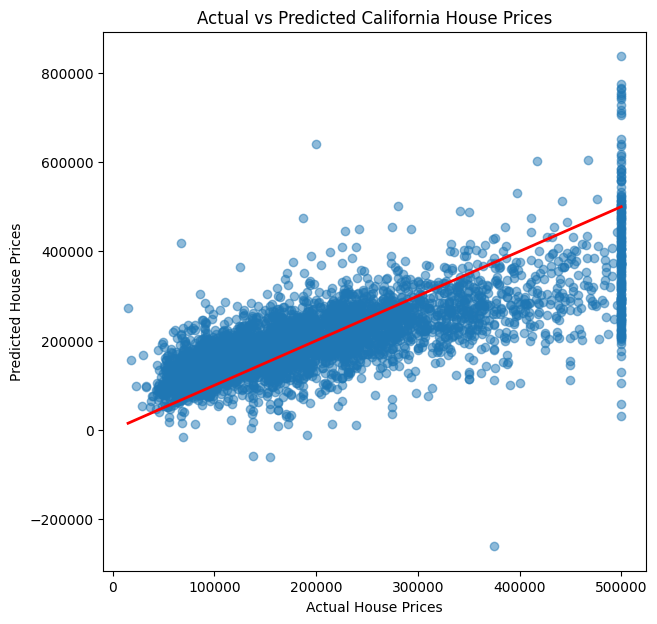

In [14]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted California House Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', lw=2)  # perfect line
plt.show()


📊 New Data Predictions:
   MedInc  HouseAge  AveRooms  Population  AveOccup  PredictedPrice
0     8.0      25.0       6.0      1200.0       3.0    1.011437e+08
1     2.5      15.0       4.0       500.0       2.0    4.220901e+07
2     5.5      30.0       7.0      2000.0       4.5    1.675738e+08


c:\Users\lenovo\tf_env\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


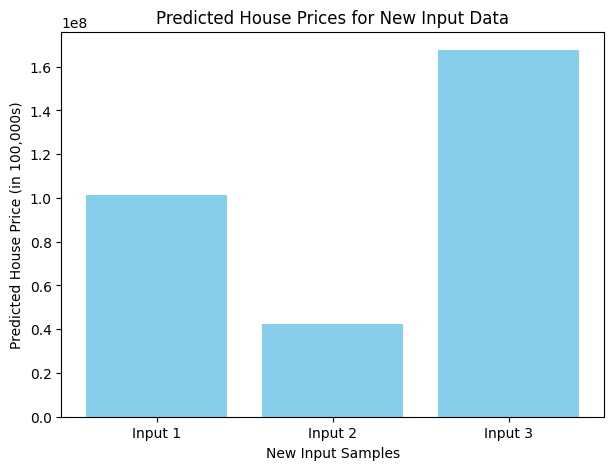

In [15]:
# 6️⃣ Input new data (custom features)
# Format: [MedInc, HouseAge, AveRooms, Population, AveOccup]
new_data = pd.DataFrame([
    [8.0, 25.0, 6.0, 1200.0, 3.0],   # Example 1: higher income, medium population
    [2.5, 15.0, 4.0, 500.0, 2.0],    # Example 2: lower income
    [5.5, 30.0, 7.0, 2000.0, 4.5]    # Example 3: moderate income and population
], columns=['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup'])

# 7️⃣ Predict for new input
new_pred = model.predict(new_data)

# Combine input and output for display
results = new_data.copy()
results['PredictedPrice'] = new_pred
print("\n📊 New Data Predictions:")
print(results)

# 8️⃣ Visualization — Predicted Prices for New Inputs
plt.figure(figsize=(7,5))
plt.bar(results.index, results['PredictedPrice'], color='skyblue')
plt.xticks(results.index, [f'Input {i+1}' for i in results.index])
plt.xlabel("New Input Samples")
plt.ylabel("Predicted House Price (in 100,000s)")
plt.title("Predicted House Prices for New Input Data")
plt.show()